lr baseline

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

# =========================================================
# 0. settings
# =========================================================
SEED = 42
N_HVG = 2000
N_SVD = 50
LABEL_ORDER = ["alpha", "beta", "delta", "pp"]

PROJECT_DIR = Path(".")
DATA_DIR = PROJECT_DIR / "data" / "processed"
RESULT_DIR = PROJECT_DIR / "results" / "baseline_lr"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

REF_PATH = DATA_DIR / "pancreas_ref_log1p_endocrine4_sharedgenes.h5ad"
CONTROL_PATH = DATA_DIR / "pancreas_query_control_log1p_endocrine4_sharedgenes.h5ad"
AAB_PATH = DATA_DIR / "pancreas_query_aab_log1p_endocrine4_sharedgenes.h5ad"
T1D_PATH = DATA_DIR / "pancreas_query_t1d_log1p_endocrine4_sharedgenes.h5ad"


# =========================================================
# 1. helper functions
# =========================================================
def to_csr_float32(X):
    """Convert matrix to CSR sparse float32."""
    if sparse.issparse(X):
        return X.tocsr().astype(np.float32)
    return sparse.csr_matrix(np.asarray(X, dtype=np.float32))


def check_same_genes(adatas):
    """Ensure all AnnData objects have identical var_names and order."""
    ref_genes = adatas[0].var_names
    for i, a in enumerate(adatas[1:], start=2):
        if not ref_genes.equals(a.var_names):
            raise ValueError(f"Gene order mismatch between dataset 1 and dataset {i}.")


def select_hvgs_from_reference(adata_ref, n_top_genes=2000):
    """
    Select HVGs using the reference dataset only.
    Prefer raw counts stored in layers['counts'] if available.
    """
    tmp = adata_ref.copy()

    if "counts" in tmp.layers:
        sc.pp.highly_variable_genes(
            tmp,
            layer="counts",
            flavor="seurat_v3",
            n_top_genes=min(n_top_genes, tmp.n_vars),
            subset=False
        )
    else:
        # fallback if counts layer is not available
        sc.pp.highly_variable_genes(
            tmp,
            flavor="seurat",
            n_top_genes=min(n_top_genes, tmp.n_vars),
            subset=False
        )

    hvg_mask = tmp.var["highly_variable"].fillna(False).to_numpy()
    hvg_genes = tmp.var_names[hvg_mask]

    if len(hvg_genes) == 0:
        raise ValueError("No HVGs selected. Please check the input data.")

    return hvg_genes


def subset_to_genes(adata, genes):
    """Subset AnnData to selected genes."""
    return adata[:, genes].copy()


def evaluate_dataset(name, X_test, y_test, model, obs_names, out_dir):
    """Evaluate one query dataset and save outputs."""
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=LABEL_ORDER, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=LABEL_ORDER, average="weighted", zero_division=0
    )

    metrics_df = pd.DataFrame([{
        "dataset": name,
        "n_cells": len(y_test),
        "accuracy": acc,
        "macro_precision": p_macro,
        "macro_recall": r_macro,
        "macro_f1": f1_macro,
        "weighted_precision": p_weighted,
        "weighted_recall": r_weighted,
        "weighted_f1": f1_weighted
    }])
    metrics_df.to_csv(out_dir / f"{name}_metrics.csv", index=False)

    report = classification_report(
        y_test,
        y_pred,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).T
    report_df.to_csv(out_dir / f"{name}_classification_report.csv")

    cm = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
    cm_df = pd.DataFrame(cm, index=LABEL_ORDER, columns=LABEL_ORDER)
    cm_df.to_csv(out_dir / f"{name}_confusion_matrix.csv")

    pred_df = pd.DataFrame({
        "cell_id": obs_names,
        "y_true": y_test,
        "y_pred": y_pred
    })
    pred_df.to_csv(out_dir / f"{name}_predictions.csv", index=False)

    # plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(out_dir / f"{name}_confusion_matrix.png", dpi=200)
    plt.close()

    print(f"\n===== {name} =====")
    print(metrics_df.to_string(index=False))

    return metrics_df


# =========================================================
# 2. load processed datasets
# =========================================================
print("Loading processed datasets...")

adata_ref = sc.read_h5ad(REF_PATH)
adata_control = sc.read_h5ad(CONTROL_PATH)
adata_aab = sc.read_h5ad(AAB_PATH)
adata_t1d = sc.read_h5ad(T1D_PATH)

print("Reference:", adata_ref)
print("Control:", adata_control)
print("AAB:", adata_aab)
print("T1D:", adata_t1d)

# sanity check
check_same_genes([adata_ref, adata_control, adata_aab, adata_t1d])

print("\nLabel counts:")
print("\nReference")
print(adata_ref.obs["label"].value_counts())
print("\nControl")
print(adata_control.obs["label"].value_counts())
print("\nAAB")
print(adata_aab.obs["label"].value_counts())
print("\nT1D")
print(adata_t1d.obs["label"].value_counts())


# =========================================================
# 3. select HVGs from reference
# =========================================================
print("\nSelecting HVGs from reference...")
hvg_genes = select_hvgs_from_reference(adata_ref, n_top_genes=N_HVG)
print(f"Number of HVGs selected: {len(hvg_genes)}")

pd.DataFrame({"gene_id": hvg_genes}).to_csv(
    RESULT_DIR / "selected_hvgs.csv", index=False
)

# subset all datasets to HVGs
adata_ref_hvg = subset_to_genes(adata_ref, hvg_genes)
adata_control_hvg = subset_to_genes(adata_control, hvg_genes)
adata_aab_hvg = subset_to_genes(adata_aab, hvg_genes)
adata_t1d_hvg = subset_to_genes(adata_t1d, hvg_genes)

print("\nShapes after HVG subsetting:")
print("Reference:", adata_ref_hvg.shape)
print("Control:", adata_control_hvg.shape)
print("AAB:", adata_aab_hvg.shape)
print("T1D:", adata_t1d_hvg.shape)


# =========================================================
# 4. prepare matrices
# =========================================================
X_train = to_csr_float32(adata_ref_hvg.X)
y_train = adata_ref_hvg.obs["label"].astype(str).to_numpy()

X_control = to_csr_float32(adata_control_hvg.X)
y_control = adata_control_hvg.obs["label"].astype(str).to_numpy()

X_aab = to_csr_float32(adata_aab_hvg.X)
y_aab = adata_aab_hvg.obs["label"].astype(str).to_numpy()

X_t1d = to_csr_float32(adata_t1d_hvg.X)
y_t1d = adata_t1d_hvg.obs["label"].astype(str).to_numpy()

print("\nMatrix shapes:")
print("X_train:", X_train.shape)
print("X_control:", X_control.shape)
print("X_aab:", X_aab.shape)
print("X_t1d:", X_t1d.shape)


# =========================================================
# 5. build model
# =========================================================
n_components = min(N_SVD, X_train.shape[1] - 1)

model = Pipeline([
    ("svd", TruncatedSVD(n_components=n_components, random_state=SEED)),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED
    ))
])

print(f"\nTraining baseline model with {X_train.shape[1]} HVGs and {n_components} SVD components...")
model.fit(X_train, y_train)

# save trained model
joblib.dump(model, RESULT_DIR / "baseline_lr_svd_model.joblib")


# =========================================================
# 6. evaluate
# =========================================================
all_metrics = []

metrics_control = evaluate_dataset(
    name="control",
    X_test=X_control,
    y_test=y_control,
    model=model,
    obs_names=adata_control_hvg.obs_names,
    out_dir=RESULT_DIR
)
all_metrics.append(metrics_control)

metrics_aab = evaluate_dataset(
    name="aab",
    X_test=X_aab,
    y_test=y_aab,
    model=model,
    obs_names=adata_aab_hvg.obs_names,
    out_dir=RESULT_DIR
)
all_metrics.append(metrics_aab)

metrics_t1d = evaluate_dataset(
    name="t1d",
    X_test=X_t1d,
    y_test=y_t1d,
    model=model,
    obs_names=adata_t1d_hvg.obs_names,
    out_dir=RESULT_DIR
)
all_metrics.append(metrics_t1d)

all_metrics_df = pd.concat(all_metrics, ignore_index=True)
all_metrics_df.to_csv(RESULT_DIR / "all_metrics_summary.csv", index=False)

print("\nSaved overall summary:")
print(all_metrics_df.to_string(index=False))

print(f"\nDone. Results saved to: {RESULT_DIR.resolve()}")


Loading processed datasets...
Reference: AnnData object with n_obs × n_vars = 26474 × 24237
    obs: 'sample', 'louvain_anno_broad', 'louvain_anno_fine', 'donor_id', 'BMI', 'HbA1c', 'insulin_content', 'glucose_SI', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'n_genes', 'n_counts', 'mt_frac', 'size_factors', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'cell_type_original', 'label', 'dataset_name', 'dataset_role', 'cohort', 'n_genes_by_counts', 'total_counts'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'gene_symbol', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'batch_condition', 'citation', 'defau

kNN baseline

Number of HVGs loaded from LR baseline: 2000
Reference: (26474, 2000)
Control: (8669, 2000)
AAB: (13122, 2000)
T1D: (3267, 2000)

Matrix shapes:
X_train: (26474, 2000)
X_control: (8669, 2000)
X_aab: (13122, 2000)
X_t1d: (3267, 2000)

Training kNN baseline with 2000 HVGs, 50 SVD components, k=15...


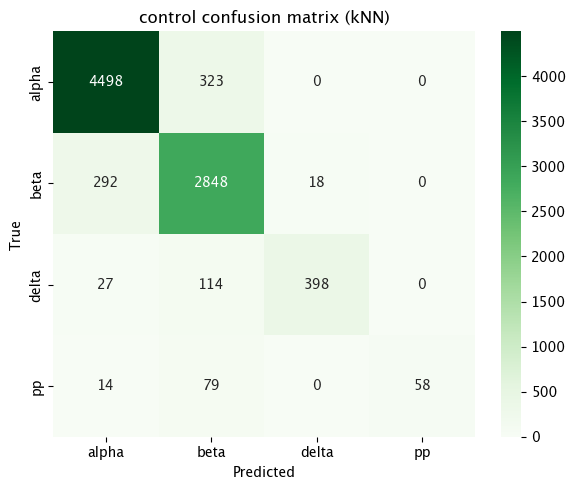


===== control =====
dataset  n_cells  accuracy  macro_precision  macro_recall  macro_f1  weighted_precision  weighted_recall  weighted_f1
control     8669  0.899988         0.933603      0.739337   0.79848            0.903099         0.899988     0.897964


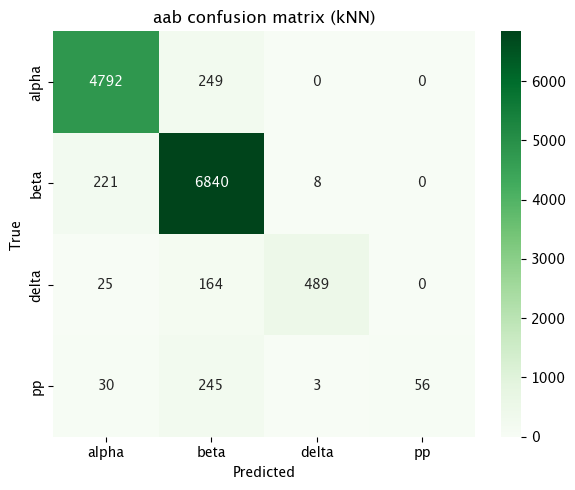


===== aab =====
dataset  n_cells  accuracy  macro_precision  macro_recall  macro_f1  weighted_precision  weighted_recall  weighted_f1
    aab    13122  0.927984         0.958946      0.701778  0.751144            0.930666         0.927984      0.92033


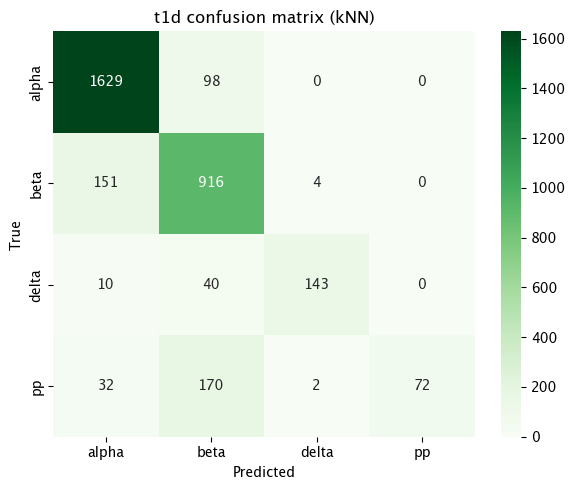


===== t1d =====
dataset  n_cells  accuracy  macro_precision  macro_recall  macro_f1  weighted_precision  weighted_recall  weighted_f1
    t1d     3267  0.844812         0.900543      0.700083  0.741578            0.859134         0.844812     0.831323

Saved overall summary:
dataset  n_cells  accuracy  macro_precision  macro_recall  macro_f1  weighted_precision  weighted_recall  weighted_f1
control     8669  0.899988         0.933603      0.739337  0.798480            0.903099         0.899988     0.897964
    aab    13122  0.927984         0.958946      0.701778  0.751144            0.930666         0.927984     0.920330
    t1d     3267  0.844812         0.900543      0.700083  0.741578            0.859134         0.844812     0.831323

Done. Results saved to: /Users/zhuqin/Desktop/CMML/ICA2/results/baseline_knn


In [2]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# =========================================================
# 0. settings
# =========================================================
SEED = 42
N_SVD = 50
K = 15
LABEL_ORDER = ["alpha", "beta", "delta", "pp"]

PROJECT_DIR = Path(".")
LR_RESULT_DIR = PROJECT_DIR / "results" / "baseline_lr"
KNN_RESULT_DIR = PROJECT_DIR / "results" / "baseline_knn"
KNN_RESULT_DIR.mkdir(parents=True, exist_ok=True)

HVG_PATH = LR_RESULT_DIR / "selected_hvgs.csv"


# =========================================================
# 1. helper functions
# =========================================================
def to_csr_float32(X):
    if sparse.issparse(X):
        return X.tocsr().astype(np.float32)
    return sparse.csr_matrix(np.asarray(X, dtype=np.float32))

def load_hvgs(hvg_path):
    if not hvg_path.exists():
        raise FileNotFoundError(f"HVG file not found: {hvg_path}")
    hvg_df = pd.read_csv(hvg_path)
    if "gene_id" not in hvg_df.columns:
        raise ValueError(f"`gene_id` column not found in {hvg_path}")
    return pd.Index(hvg_df["gene_id"].astype(str).tolist())

def subset_to_genes(adata, genes):
    missing = genes.difference(adata.var_names)
    if len(missing) > 0:
        raise ValueError(f"{len(missing)} HVGs not found in dataset.")
    return adata[:, genes].copy()

def evaluate_dataset(name, X_test, y_test, model, obs_names, out_dir):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=LABEL_ORDER, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=LABEL_ORDER, average="weighted", zero_division=0
    )

    metrics_df = pd.DataFrame([{
        "dataset": name,
        "n_cells": len(y_test),
        "accuracy": acc,
        "macro_precision": p_macro,
        "macro_recall": r_macro,
        "macro_f1": f1_macro,
        "weighted_precision": p_weighted,
        "weighted_recall": r_weighted,
        "weighted_f1": f1_weighted
    }])
    metrics_df.to_csv(out_dir / f"{name}_metrics.csv", index=False)

    report = classification_report(
        y_test,
        y_pred,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).T
    report_df.to_csv(out_dir / f"{name}_classification_report.csv")

    cm = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
    cm_df = pd.DataFrame(cm, index=LABEL_ORDER, columns=LABEL_ORDER)
    cm_df.to_csv(out_dir / f"{name}_confusion_matrix.csv")

    pred_df = pd.DataFrame({
        "cell_id": obs_names,
        "y_true": y_test,
        "y_pred": y_pred
    })
    pred_df.to_csv(out_dir / f"{name}_predictions.csv", index=False)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens")
    plt.title(f"{name} confusion matrix (kNN)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(out_dir / f"{name}_confusion_matrix.png", dpi=200)
    plt.show()
    plt.close()

    print(f"\n===== {name} =====")
    print(metrics_df.to_string(index=False))

    return metrics_df, report_df, cm_df


# =========================================================
# 2. load HVGs from LR baseline
# =========================================================
hvg_genes = load_hvgs(HVG_PATH)
print(f"Number of HVGs loaded from LR baseline: {len(hvg_genes)}")

pd.DataFrame({"gene_id": hvg_genes}).to_csv(
    KNN_RESULT_DIR / "selected_hvgs.csv", index=False
)

# subset all datasets to the same HVGs
adata_ref_hvg = subset_to_genes(adata_ref, hvg_genes)
adata_control_hvg = subset_to_genes(adata_control, hvg_genes)
adata_aab_hvg = subset_to_genes(adata_aab, hvg_genes)
adata_t1d_hvg = subset_to_genes(adata_t1d, hvg_genes)

print("Reference:", adata_ref_hvg.shape)
print("Control:", adata_control_hvg.shape)
print("AAB:", adata_aab_hvg.shape)
print("T1D:", adata_t1d_hvg.shape)


# =========================================================
# 3. prepare matrices
# =========================================================
X_train = to_csr_float32(adata_ref_hvg.X)
y_train = adata_ref_hvg.obs["label"].astype(str).to_numpy()

X_control = to_csr_float32(adata_control_hvg.X)
y_control = adata_control_hvg.obs["label"].astype(str).to_numpy()

X_aab = to_csr_float32(adata_aab_hvg.X)
y_aab = adata_aab_hvg.obs["label"].astype(str).to_numpy()

X_t1d = to_csr_float32(adata_t1d_hvg.X)
y_t1d = adata_t1d_hvg.obs["label"].astype(str).to_numpy()

print("\nMatrix shapes:")
print("X_train:", X_train.shape)
print("X_control:", X_control.shape)
print("X_aab:", X_aab.shape)
print("X_t1d:", X_t1d.shape)


# =========================================================
# 4. build and train kNN baseline
# =========================================================
n_components = min(N_SVD, X_train.shape[1] - 1)

knn_model = Pipeline([
    ("svd", TruncatedSVD(n_components=n_components, random_state=SEED)),
    ("knn", KNeighborsClassifier(
        n_neighbors=K,
        weights="distance",
        metric="euclidean",
        n_jobs=1
    ))
])

print(f"\nTraining kNN baseline with {X_train.shape[1]} HVGs, {n_components} SVD components, k={K}...")
knn_model.fit(X_train, y_train)

joblib.dump(knn_model, KNN_RESULT_DIR / "baseline_knn_svd_model.joblib")


# =========================================================
# 5. evaluate
# =========================================================
all_metrics = []

metrics_control, report_control, cm_control = evaluate_dataset(
    name="control",
    X_test=X_control,
    y_test=y_control,
    model=knn_model,
    obs_names=adata_control_hvg.obs_names,
    out_dir=KNN_RESULT_DIR
)
all_metrics.append(metrics_control)

metrics_aab, report_aab, cm_aab = evaluate_dataset(
    name="aab",
    X_test=X_aab,
    y_test=y_aab,
    model=knn_model,
    obs_names=adata_aab_hvg.obs_names,
    out_dir=KNN_RESULT_DIR
)
all_metrics.append(metrics_aab)

metrics_t1d, report_t1d, cm_t1d = evaluate_dataset(
    name="t1d",
    X_test=X_t1d,
    y_test=y_t1d,
    model=knn_model,
    obs_names=adata_t1d_hvg.obs_names,
    out_dir=KNN_RESULT_DIR
)
all_metrics.append(metrics_t1d)

all_metrics_df = pd.concat(all_metrics, ignore_index=True)
all_metrics_df.to_csv(KNN_RESULT_DIR / "all_metrics_summary.csv", index=False)

print("\nSaved overall summary:")
print(all_metrics_df.to_string(index=False))
print(f"\nDone. Results saved to: {KNN_RESULT_DIR.resolve()}")


In [3]:
import pandas as pd

lr = pd.read_csv("results/baseline_lr/all_metrics_summary.csv")
lr["method"] = "LR"

knn = pd.read_csv("results/baseline_knn/all_metrics_summary.csv")
knn["method"] = "kNN"

compare = pd.concat([lr, knn], ignore_index=True)
compare = compare[[
    "dataset", "method", "accuracy",
    "macro_precision", "macro_recall", "macro_f1",
    "weighted_precision", "weighted_recall", "weighted_f1"
]]
compare.sort_values(["dataset", "method"])


,dataset,method,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
1,aab,LR,0.915181,0.919207,0.770007,0.821840,0.917801,0.915181,0.912611
4,aab,kNN,0.927984,0.958946,0.701778,0.751144,0.930666,0.927984,0.920330
0,control,LR,0.869997,0.882487,0.740060,0.795503,0.871186,0.869997,0.866563
3,control,kNN,0.899988,0.933603,0.739337,0.798480,0.903099,0.899988,0.897964
2,t1d,LR,0.888889,0.910758,0.807784,0.849830,0.892818,0.888889,0.885415
5,t1d,kNN,0.844812,0.900543,0.700083,0.741578,0.859134,0.844812,0.831323


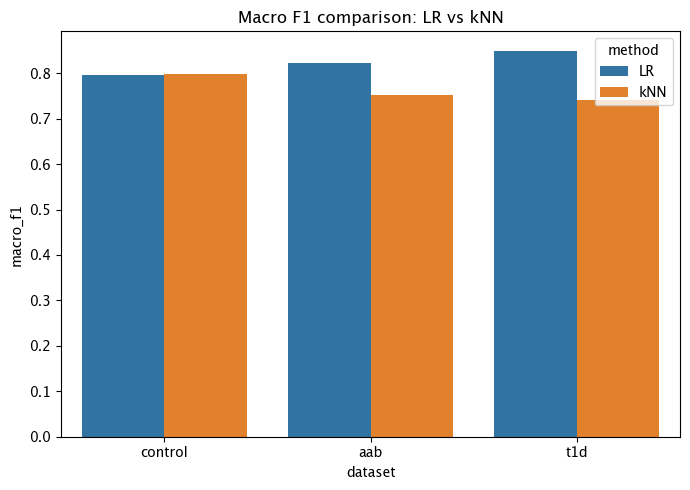

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.barplot(data=compare, x="dataset", y="macro_f1", hue="method")
plt.title("Macro F1 comparison: LR vs kNN")
plt.tight_layout()
plt.show()


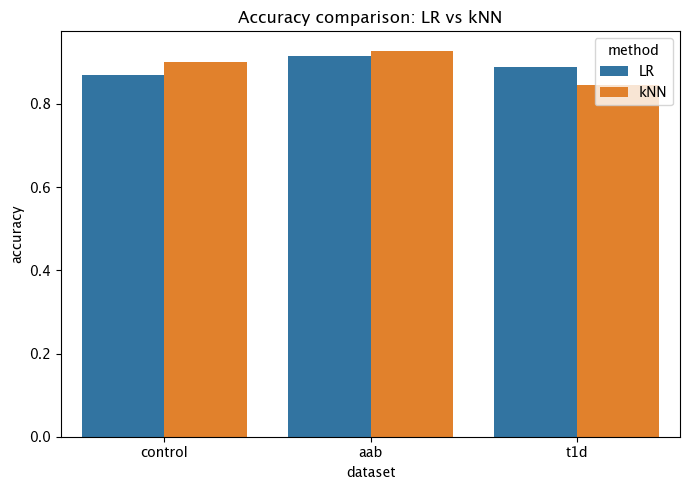

In [5]:
plt.figure(figsize=(7,5))
sns.barplot(data=compare, x="dataset", y="accuracy", hue="method")
plt.title("Accuracy comparison: LR vs kNN")
plt.tight_layout()
plt.show()


In [1]:
import os
print(os.getcwd())


/Users/zhuqin/Desktop/CMML/ICA2


In [ ]:
from pathlib import Path
import pandas as pd
import scanpy as sc
from scipy import sparse, io as spio

PROJECT_DIR = Path(".")

DATA_DIR = PROJECT_DIR / "data" / "processed"
LR_RESULT_DIR = PROJECT_DIR / "results" / "baseline_lr"
SINGLER_DIR = PROJECT_DIR / "results" / "baseline_singler"
SINGLER_INPUT_DIR = SINGLER_DIR / "input"

SINGLER_DIR.mkdir(parents=True, exist_ok=True)
SINGLER_INPUT_DIR.mkdir(parents=True, exist_ok=True)

REF_PATH = DATA_DIR / "pancreas_ref_log1p_endocrine4_sharedgenes.h5ad"
CONTROL_PATH = DATA_DIR / "pancreas_query_control_log1p_endocrine4_sharedgenes.h5ad"
AAB_PATH = DATA_DIR / "pancreas_query_aab_log1p_endocrine4_sharedgenes.h5ad"
T1D_PATH = DATA_DIR / "pancreas_query_t1d_log1p_endocrine4_sharedgenes.h5ad"

HVG_PATH = LR_RESULT_DIR / "selected_hvgs.csv"

print("DATA_DIR exists:", DATA_DIR.exists())
print("HVG_PATH exists:", HVG_PATH.exists())


DATA_DIR exists: True
HVG_PATH exists: True


In [3]:
adata_ref = sc.read_h5ad(REF_PATH)
adata_control = sc.read_h5ad(CONTROL_PATH)
adata_aab = sc.read_h5ad(AAB_PATH)
adata_t1d = sc.read_h5ad(T1D_PATH)

print("Reference:", adata_ref)
print("Control:", adata_control)
print("AAB:", adata_aab)
print("T1D:", adata_t1d)

Reference: AnnData object with n_obs × n_vars = 26474 × 24237
    obs: 'sample', 'louvain_anno_broad', 'louvain_anno_fine', 'donor_id', 'BMI', 'HbA1c', 'insulin_content', 'glucose_SI', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'n_genes', 'n_counts', 'mt_frac', 'size_factors', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'cell_type_original', 'label', 'dataset_name', 'dataset_role', 'cohort', 'n_genes_by_counts', 'total_counts'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'gene_symbol', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'batch_condition', 'citation', 'default_embedding', 'log1p', 'organ

In [4]:
hvg_df = pd.read_csv(HVG_PATH)
hvg_genes = pd.Index(hvg_df["gene_id"].astype(str).tolist())

print("Number of HVGs loaded:", len(hvg_genes))
print(hvg_genes[:5].tolist())


Number of HVGs loaded: 2000
['ENSG00000187634', 'ENSG00000188290', 'ENSG00000187608', 'ENSG00000186891', 'ENSG00000149527']


In [5]:
def subset_to_genes(adata, genes):
    missing = genes.difference(adata.var_names)
    if len(missing) > 0:
        raise ValueError(f"{len(missing)} HVGs not found in dataset.")
    return adata[:, genes].copy()

adata_ref_hvg = subset_to_genes(adata_ref, hvg_genes)
adata_control_hvg = subset_to_genes(adata_control, hvg_genes)
adata_aab_hvg = subset_to_genes(adata_aab, hvg_genes)
adata_t1d_hvg = subset_to_genes(adata_t1d, hvg_genes)

print("Reference:", adata_ref_hvg.shape)
print("Control:", adata_control_hvg.shape)
print("AAB:", adata_aab_hvg.shape)
print("T1D:", adata_t1d_hvg.shape)


Reference: (26474, 2000)
Control: (8669, 2000)
AAB: (13122, 2000)
T1D: (3267, 2000)


In [7]:
def export_for_singler(adata, prefix, out_dir):
    """
    Export log1p expression matrix for SingleR.
    Output:
      - prefix_logcounts.mtx   (genes x cells)
      - prefix_genes.csv
      - prefix_meta.csv
    """
    X = adata.X
    if not sparse.issparse(X):
        X = sparse.csr_matrix(X)

    # SingleR / SingleCellExperiment 常用 genes x cells
    X = X.T.tocsc()
    spio.mmwrite(out_dir / f"{prefix}_logcounts.mtx", X)

    genes_df = pd.DataFrame({
        "gene_id": adata.var_names.astype(str)
    })

    if "gene_symbol" in adata.var.columns:
        genes_df["gene_symbol"] = adata.var["gene_symbol"].astype(str).values

    genes_df.to_csv(out_dir / f"{prefix}_genes.csv", index=False)

    meta_cols = [
        "label",
        "cell_type",
        "cell_type_original",
        "donor_id",
        "disease",
        "disease_state",
        "sex",
        "assay",
        "dataset_name",
        "dataset_role",
        "cohort",
    ]
    keep_cols = [c for c in meta_cols if c in adata.obs.columns]

    meta_df = adata.obs[keep_cols].copy()
    meta_df.insert(0, "cell_id", adata.obs_names.astype(str))
    meta_df.to_csv(out_dir / f"{prefix}_meta.csv", index=False)

    print(f"Exported {prefix}:")
    print("  matrix:", (out_dir / f"{prefix}_logcounts.mtx").name)
    print("  genes :", (out_dir / f"{prefix}_genes.csv").name)
    print("  meta  :", (out_dir / f"{prefix}_meta.csv").name)

export_for_singler(adata_ref_hvg, "ref", SINGLER_INPUT_DIR)
export_for_singler(adata_control_hvg, "control", SINGLER_INPUT_DIR)
export_for_singler(adata_aab_hvg, "aab", SINGLER_INPUT_DIR)
export_for_singler(adata_t1d_hvg, "t1d", SINGLER_INPUT_DIR)

print("\nExport done:", SINGLER_INPUT_DIR.resolve())



Exported ref:
  matrix: ref_logcounts.mtx
  genes : ref_genes.csv
  meta  : ref_meta.csv
Exported control:
  matrix: control_logcounts.mtx
  genes : control_genes.csv
  meta  : control_meta.csv
Exported aab:
  matrix: aab_logcounts.mtx
  genes : aab_genes.csv
  meta  : aab_meta.csv
Exported t1d:
  matrix: t1d_logcounts.mtx
  genes : t1d_genes.csv
  meta  : t1d_meta.csv

Export done: /Users/zhuqin/Desktop/CMML/ICA2/results/baseline_singler/input


In [8]:
for f in sorted(SINGLER_INPUT_DIR.iterdir()):
    print(f.name)


aab_genes.csv
aab_logcounts.mtx
aab_meta.csv
control_genes.csv
control_logcounts.mtx
control_meta.csv
ref_genes.csv
ref_logcounts.mtx
ref_meta.csv
t1d_genes.csv
t1d_logcounts.mtx
t1d_meta.csv


SingleR will run in Rstudio. 